<link rel="stylesheet" href="notebooks/styles.css">


<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>


# Module 1: *Data Exploration*
##### Version Number: 4.0
---
### Contents  
> 1. *Weather Data* 
> 2. *Wildfire Data*
> 3. *Mesh Network*
---
### Notes
- Integrate wildfire impact data with daily weather data from extracted from gridMET.
### Inputs
- Daily Weather Readings - `gridmet_final.csv` 
- Wildfire Damage Data - `clean_fires.csv` (cleaned in module 1)
- California Mesh Sampling Grid - `sampling_grids.csv` (built in appendix A) 
---
### Outputs  
---
### User Created Dependencies  


In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---
### Third Party Dependencies

In [2]:
# Data handling
import pandas as pd
import numpy as np
import geopandas as gpd
import datetime as dt

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
import matplotlib.ticker as ticker

---

In [3]:
pd.set_option('display.max_colwidth', None)

## 1. Weather Data - `gridmet_final.csv`

> ### Source:
> Weather variables (temperature, precipitation, humidity, etc.) were sourced from gridMET, a high-resolution (~4 km) gridded 
> dataset of daily meteorological data for the contiguous United States.\
> URL: https://www.climatologylab.org/gridmet.html

In [4]:
weather = pd.read_csv('../data/raw/gridmet_final.csv')
weather_meta = pd.read_csv('../data/raw/weather_meta.csv')

In [5]:
weather_meta

,Full Name,Units,Description
0,Daily Maximum Air Temperature,°C,Maximum air temperature at 2 meters above ground (Kelvin)
1,Daily Minimum Air Temperature,°C,Minimum air temperature at 2 meters above ground (Kelvin)
2,Vapor Pressure Deficit,kPa,Difference between saturation vapor pressure and actual vapor pressure (kPa); indicates atmospheric drying power
3,Maximum Relative Humidity,%,Maximum daily relative humidity (%) at 2 meters
4,Minimum Relative Humidity,%,Minimum daily relative humidity (%) at 2 meters
5,Specific Humidity,kg/kg,Mass of water vapor per unit mass of air (kg/kg)
6,Precipitation,mm,Daily total precipitation (mm)
7,Wind Speed,m/s,Daily wind speed (m/s) at 10 meters
8,Solar Radiation,W/m²,Daily incoming shortwave radiation (W/m²)
9,Actual Evapotranspiration,mm,Estimated evapotranspiration from actual vegetation (mm/day)


In [6]:
basic_explore(weather)

Rows:  446340  Columns:  22


Duplicates  0
Total NA values:  0  of  9819480 datapoints


## 2. Wildfire Data - `fire_data.csv`


Wildfire data was sourced from publically available records from the Cal Fire website. Estimation and cleaning are presented in Appendix B.

Source: [CAL FIRE – Fire Incidents](https://www.fire.ca.gov/)  


- `Date` - Date fire started
- `County` - County fire is located in
- `Fire Name` - Official fire name for California
- `FinalAcres` - Total acres burned per wildfire incident
- `Estimated Damage` - Damages caused by wildfire incidents as estimated in Appendix B
- `Fire_Latitude`,`Fire_Longitude` - Spatial data for wildfire start location

In [7]:
fire_data = pd.read_csv("../data/processed/fire_data.csv")
basic_explore(fire_data)

Rows:  76791  Columns:  9
Duplicates  93
Total NA values:  0  of  691119 datapoints


In [8]:
fire_data

,Acres,Estimated_Damage,Date,Fire_Latitude,Fire_Longitude,Fire Name,Estimated_Damage_has_data,Acres_has_data,buffer
0,0.00,0.0,2018-01-01,34.031731,-117.950401,lac-393275,0,0,23000.0
1,0.10,0.0,2018-01-01,34.560180,-115.642300,tire,0,1,23000.0
2,0.00,0.0,2018-01-01,34.682388,-118.085892,lac-393502,0,0,23000.0
3,0.00,0.0,2018-01-01,33.930191,-118.343903,lac-393384,0,0,23000.0
4,0.00,0.0,2018-01-01,33.985970,-118.174149,lac-393431,0,0,23000.0
...,...,...,...,...,...,...,...,...,...
76786,0.00,0.0,2025-07-13,34.671700,-118.127710,lac-242317,0,0,23000.0
76787,0.00,0.0,2025-07-13,34.363060,-118.504500,white,0,0,23000.0
76788,0.01,0.0,2025-07-13,37.345361,-120.607489,atwater bl / first st,0,1,23000.0
76789,0.07,0.0,2025-07-13,38.516749,-122.982029,river,0,1,23000.0


In [9]:
after_total = fire_data['Estimated_Damage'].values.sum()
total_fires = len(fire_data[fire_data['Estimated_Damage'] > 0])
print(f"Total Estimated Value: ${after_total:,.0f} in {total_fires} wildfires.")

Total Estimated Value: $8,384,513,303 in 538 wildfires.


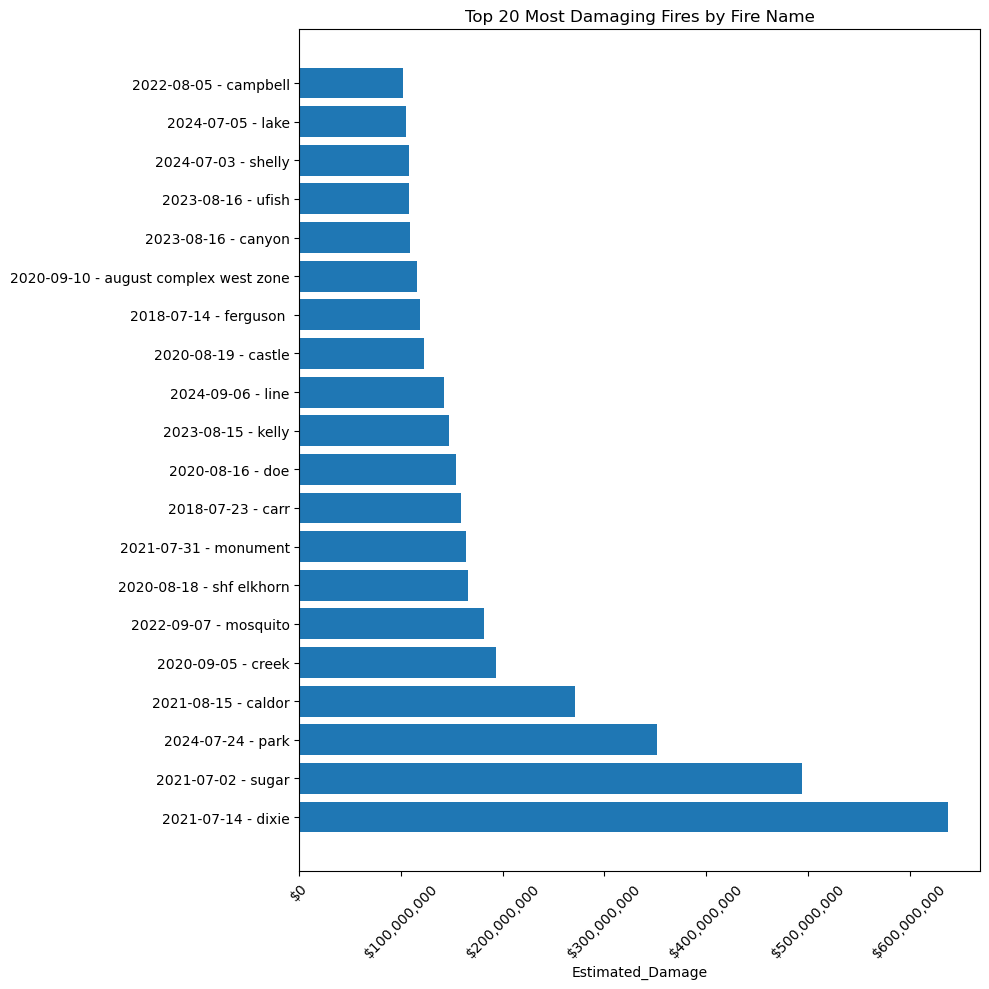

In [10]:
top_days = fire_data.sort_values('Estimated_Damage', ascending=False).head(20)
plt.figure(figsize=(10, 10))
plt.barh(top_days['Date'].astype(str) + ' - ' + top_days['Fire Name'], top_days['Estimated_Damage'])
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.title("Top 20 Most Damaging Fires by Fire Name")
plt.xlabel("Estimated_Damage")
plt.xticks(rotation=45)
plt.tight_layout()

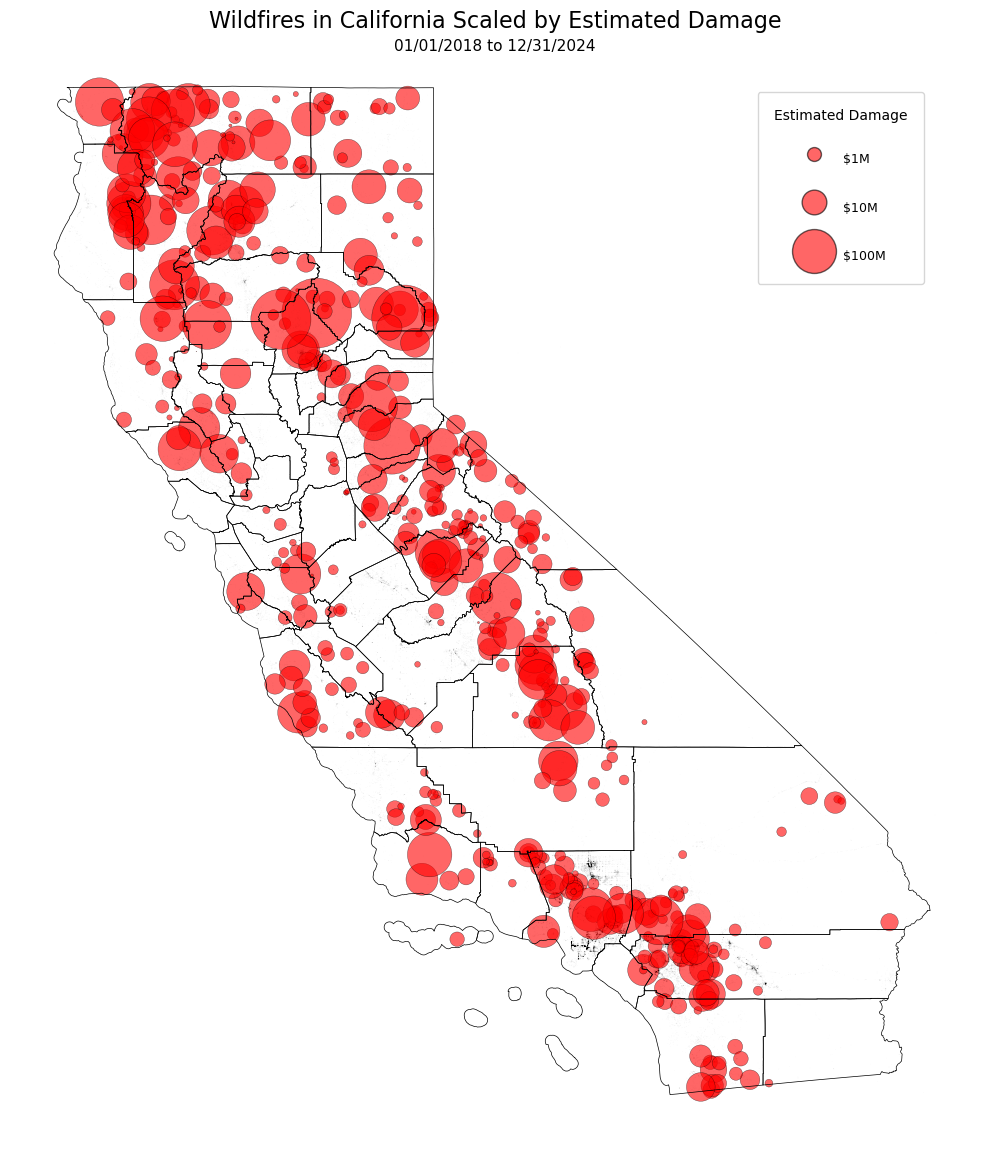

In [11]:
fire_data_gdf = gpd.GeoDataFrame(
    fire_data,
    geometry=gpd.points_from_xy(fire_data['Fire_Longitude'], fire_data['Fire_Latitude']),
    crs='EPSG:4326'
)
plot_fire_damage(fire_data_gdf,'Estimated_Damage')

### 3. Load Sampling Grids - `Sampling_grids.csv`

<img src="../data/maps/grids.png" width="400">

In [12]:
## Load file
sample_meta = pd.read_csv("../data/raw/Sampling_grids_meta.csv")
sample_meta

,Field Name,Alias,Data Type,Description,Units,Category
0,grid_id,Grid ID,Long,Unique number representing each sampling grid,none,Grid
1,centroid_easting,easting,Double,EPSG 3310 easting position of each grids centroid,meters,Location
2,centroid_northing,northing,Double,EPSG 3310 northing position of each grids centroid,meters,Location
3,Influence_Zone,Influence Zone,Double,Total amount io influence areas within each grid,square meters,WUI
4,interface_zone,Interface,Double,Total amount io interface areas within each grid,square meters,WUI
5,intermix_zone,Intermix,Double,Total amount io intermix areas within each grid,square meters,WUI
6,dominant_province_description,Province Description,Text,Ecoregion province that makes up the most area in each grid,none,Region
7,dominant_province_percent,Dominant Province Percent,Double,Percentage of ecoregion province that makes up the most area in each grid,none,Region
8,sum_province_area,Sum Province Area,Double,Total area of ecoregion province that makes up the most area in each grid,square meters,Region
9,dominant_section_description,Section Description,Text,Ecoregion section that makes up the most area in each grid,none,Region


---